# Filtered Nutty Percept - OR Association Analysis

This notebook builds on the original nutty receptor analysis but **filters out promiscuous molecules** that bind to more than 20% of all ORs. This removes molecules that are broadly reactive across many receptors, allowing us to focus on molecules with more specific receptor binding profiles.

**Key difference from original analysis:**
- Molecules binding to >20% of all ORs are removed
- Then receptors with ≥30% activation across remaining molecules are removed

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import sys
from scipy.stats import fisher_exact

# Add parent directory to path
sys.path.insert(0, os.path.dirname(os.getcwd()))

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## 1. Load Data and Apply Molecule Promiscuity Filter

In [2]:
# Load the GS_LF dataset
gs_lf_path = '../data/datasets/NaNs_GS_LF_isomeric_SMILES_dedup_odor_filtered.csv'
df_original = pd.read_csv(gs_lf_path)

print(f"Original dataset: {len(df_original)} molecules")

Original dataset: 5862 molecules


In [ ]:
# Load OR logits (M2OR database - 1237 ORs) - WEIGHTED version
logits_path = '../data/datasets/full_weighted_1237_ORs_logits.pt'
or_logits = torch.load(logits_path)

# Move to CPU if on GPU
if or_logits.is_cuda:
    or_logits = or_logits.cpu()

# Load M2OR sequence info for OR names
mol_OR = pd.read_csv('../data/datasets/M2OR_original_mol_OR_pairs.csv', sep=';')
or_names_full = mol_OR['seq_id'].value_counts().head(1237).index.tolist()

print(f"OR logits shape: {or_logits.shape}")
print(f"Number of ORs: {or_logits.shape[1]}")

In [4]:
# Convert logits to binary predictions (threshold 0.5)
or_probs_full = torch.sigmoid(or_logits)
or_preds_full = torch.round(or_probs_full)

# Calculate how many ORs each molecule binds to
n_ors_per_molecule = or_preds_full.sum(dim=1)
n_total_ors = or_preds_full.shape[1]

# Calculate proportion of ORs each molecule binds
prop_ors_per_molecule = n_ors_per_molecule / n_total_ors

print(f"Mean ORs bound per molecule: {n_ors_per_molecule.mean().item():.1f}")
print(f"Mean proportion of ORs bound: {prop_ors_per_molecule.mean().item()*100:.1f}%")
print(f"Max proportion of ORs bound: {prop_ors_per_molecule.max().item()*100:.1f}%")

Mean ORs bound per molecule: 211.3
Mean proportion of ORs bound: 17.1%
Max proportion of ORs bound: 100.0%


In [ ]:
# Filter out molecules binding to >20% of all ORs
MOLECULE_PROMISCUITY_THRESHOLD = 0.20

non_promiscuous_mol_mask = prop_ors_per_molecule <= MOLECULE_PROMISCUITY_THRESHOLD
n_removed = (~non_promiscuous_mol_mask).sum().item()
n_remaining = non_promiscuous_mol_mask.sum().item()

print(f"Molecule promiscuity filter: removing molecules binding to >{MOLECULE_PROMISCUITY_THRESHOLD*100:.0f}% of ORs")
print(f"Molecules removed: {n_removed}")
print(f"Molecules remaining: {n_remaining}")

# Get indices of retained molecules
retained_mol_indices = non_promiscuous_mol_mask.nonzero(as_tuple=True)[0].numpy()
print(f"\nRetained molecule indices (first 10): {retained_mol_indices[:10]}")

In [6]:
# Filter both OR predictions and dataframe using the same indices
or_logits_filtered = or_logits[retained_mol_indices]
or_probs_filtered = or_probs_full[retained_mol_indices]
or_preds_filtered = or_preds_full[retained_mol_indices]

# Filter dataframe and reset index
df = df_original.iloc[retained_mol_indices].reset_index(drop=True)

print(f"Filtered OR predictions shape: {or_preds_filtered.shape}")
print(f"Filtered dataframe length: {len(df)}")

# Verify alignment
assert len(df) == or_preds_filtered.shape[0], "Dataframe and OR predictions must have same length!"

Filtered OR predictions shape: torch.Size([4355, 1237])
Filtered dataframe length: 4355


## 2. Apply OR Promiscuity Filter (>30% activation across molecules)

In [ ]:
# Filter out promiscuous ORs (those activated in ≥30% of molecules)
OR_PROMISCUITY_THRESHOLD = 0.30

or_activation_rates = or_preds_filtered.mean(dim=0)
non_promiscuous_or_mask = or_activation_rates < OR_PROMISCUITY_THRESHOLD  # strict < to get 1212
n_ors_removed = (~non_promiscuous_or_mask).sum().item()
n_ors_remaining = non_promiscuous_or_mask.sum().item()

print(f"OR promiscuity filter: removing ORs with ≥{OR_PROMISCUITY_THRESHOLD*100:.0f}% activation rate")
print(f"ORs removed: {n_ors_removed}")
print(f"ORs remaining: {n_ors_remaining}")

# Apply filter
or_preds = or_preds_filtered[:, non_promiscuous_or_mask]
or_probs = or_probs_filtered[:, non_promiscuous_or_mask]
or_names = [name for name, keep in zip(or_names_full, non_promiscuous_or_mask.tolist()) if keep]

print(f"\nFinal OR predictions shape: {or_preds.shape}")

## 3. Identify Nutty Molecules and Calculate Baseline

In [8]:
# Identify nutty molecules in filtered dataset
nutty_mask = df['nutty'] == 1
nutty_indices = df[nutty_mask].index.tolist()
non_nutty_indices = df[~nutty_mask].index.tolist()

baseline_nutty_prop = len(nutty_indices) / len(df)

print(f"Total molecules (after filtering): {len(df)}")
print(f"Molecules with 'nutty' label: {len(nutty_indices)}")
print(f"Proportion nutty: {baseline_nutty_prop*100:.2f}%")

Total molecules (after filtering): 4355
Molecules with 'nutty' label: 261
Proportion nutty: 5.99%


## 4. Identify Nutty-Associated ORs

In [9]:
# Calculate activation rates for nutty vs non-nutty molecules
nutty_or_preds = or_preds[nutty_indices]
non_nutty_or_preds = or_preds[non_nutty_indices]

nutty_activation_rate = nutty_or_preds.mean(dim=0).numpy()
non_nutty_activation_rate = non_nutty_or_preds.mean(dim=0).numpy()
activation_diff = nutty_activation_rate - non_nutty_activation_rate

print(f"Mean OR activation rate for nutty molecules: {nutty_activation_rate.mean():.4f}")
print(f"Mean OR activation rate for non-nutty molecules: {non_nutty_activation_rate.mean():.4f}")

Mean OR activation rate for nutty molecules: 0.0509
Mean OR activation rate for non-nutty molecules: 0.0411


In [10]:
# Statistical test: Fisher's exact test for each OR
p_values = []
odds_ratios = []

for or_idx in range(or_preds.shape[1]):
    nutty_on = nutty_or_preds[:, or_idx].sum().item()
    nutty_off = len(nutty_indices) - nutty_on
    non_nutty_on = non_nutty_or_preds[:, or_idx].sum().item()
    non_nutty_off = len(non_nutty_indices) - non_nutty_on
    
    table = [[nutty_on, nutty_off], [non_nutty_on, non_nutty_off]]
    
    try:
        odds_ratio, p_value = fisher_exact(table, alternative='greater')
    except:
        odds_ratio, p_value = np.nan, 1.0
    
    p_values.append(p_value)
    odds_ratios.append(odds_ratio)

# Create OR stats dataframe
or_stats = pd.DataFrame({
    'OR_index': range(or_preds.shape[1]),
    'OR_name': or_names[:or_preds.shape[1]],
    'nutty_activation_rate': nutty_activation_rate,
    'non_nutty_activation_rate': non_nutty_activation_rate,
    'activation_diff': activation_diff,
    'p_value': p_values,
    'odds_ratio': odds_ratios
})

# Bonferroni correction
or_stats['p_value_corrected'] = (or_stats['p_value'] * or_preds.shape[1]).clip(upper=1.0)

print(f"ORs with p < 0.05 (Bonferroni corrected): {(or_stats['p_value_corrected'] < 0.05).sum()}")

ORs with p < 0.05 (Bonferroni corrected): 124


In [11]:
# Top nutty-associated ORs
or_stats_sorted = or_stats.sort_values('activation_diff', ascending=False)

print("Top 20 ORs most associated with nutty percept:")
print(or_stats_sorted.head(20)[['OR_index', 'OR_name', 'nutty_activation_rate', 
                                 'non_nutty_activation_rate', 'activation_diff', 'odds_ratio']])

Top 20 ORs most associated with nutty percept:
      OR_index OR_name  nutty_activation_rate  non_nutty_activation_rate  \
537        537   s_951               0.613027                   0.218857   
1072      1072   s_953               0.601533                   0.216903   
1            1   s_418               0.601533                   0.220078   
536        536   s_412               0.628352                   0.248901   
538        538   s_253               0.570881                   0.192965   
544        544   s_547               0.528736                   0.192477   
465        465   s_226               0.524904                   0.192721   
817        817   s_756               0.367816                   0.045188   
247        247  s_1141               0.425287                   0.116268   
58          58    s_52               0.344828                   0.038349   
4            4  s_1108               0.344828                   0.050318   
568        568  s_1106               0.46

## 5. In Silico Screening: Precision and Enrichment

In [12]:
# For each top nutty-associated OR, calculate screening precision
top_n_ors = 10
top_nutty_or_indices = or_stats_sorted.head(top_n_ors)['OR_index'].tolist()

results = []
for or_idx in top_nutty_or_indices:
    binding_mask = or_preds[:, or_idx] == 1
    binding_indices = binding_mask.nonzero(as_tuple=True)[0].numpy()
    
    nutty_labels = df.iloc[binding_indices]['nutty'].values
    n_binding = len(binding_indices)
    n_nutty = nutty_labels.sum()
    prop_nutty = n_nutty / n_binding if n_binding > 0 else 0
    
    results.append({
        'OR_index': or_idx,
        'OR_name': or_stats.loc[or_stats['OR_index'] == or_idx, 'OR_name'].values[0],
        'n_molecules_binding': n_binding,
        'n_nutty': int(n_nutty),
        'proportion_nutty': prop_nutty,
        'enrichment': prop_nutty / baseline_nutty_prop if baseline_nutty_prop > 0 else 0
    })

results_df = pd.DataFrame(results)
print(f"Baseline proportion nutty: {baseline_nutty_prop*100:.2f}%\n")
print(results_df)

Baseline proportion nutty: 5.99%

   OR_index OR_name  n_molecules_binding  n_nutty  proportion_nutty  \
0       537   s_951                 1056      160          0.151515   
1      1072   s_953                 1045      157          0.150239   
2         1   s_418                 1058      157          0.148393   
3       536   s_412                 1183      164          0.138631   
4       538   s_253                  939      149          0.158679   
5       544   s_547                  926      138          0.149028   
6       465   s_226                  926      137          0.147948   
7       817   s_756                  281       96          0.341637   
8       247  s_1141                  587      111          0.189097   
9        58    s_52                  247       90          0.364372   

   enrichment  
0    2.528155  
1    2.506865  
2    2.476063  
3    2.313166  
4    2.647697  
5    2.486656  
6    2.468637  
7    5.700495  
8    3.155241  
9    6.079855  


In [13]:
# Best single OR for screening
best_or = results_df.loc[results_df['proportion_nutty'].idxmax()]
print(f"Best single OR for nutty screening:")
print(f"  {best_or['OR_name']} (index {best_or['OR_index']})")
print(f"  Precision: {best_or['proportion_nutty']*100:.1f}%")
print(f"  Enrichment: {best_or['enrichment']:.2f}x")

Best single OR for nutty screening:
  s_52 (index 58)
  Precision: 36.4%
  Enrichment: 6.08x


## 6. Nutty Odor Family Analysis (Nutty + Roasted + Meaty)

In [14]:
# Find molecules with ALL THREE percepts
NUTTY_FAMILY = ['nutty', 'roasted', 'meaty']

family_mask = (df['nutty'] == 1) & (df['roasted'] == 1) & (df['meaty'] == 1)
family_indices = df[family_mask].index.tolist()
non_family_indices = df[~family_mask].index.tolist()

baseline_family_prop = len(family_indices) / len(df)

print(f"Molecules with ALL THREE percepts: {len(family_indices)} ({baseline_family_prop*100:.2f}%)")

Molecules with ALL THREE percepts: 27 (0.62%)


In [15]:
# Identify family-associated ORs
family_or_preds = or_preds[family_indices]
non_family_or_preds = or_preds[non_family_indices]

family_activation_rate = family_or_preds.mean(dim=0).numpy()
non_family_activation_rate = non_family_or_preds.mean(dim=0).numpy()
family_activation_diff = family_activation_rate - non_family_activation_rate

# Rank ORs by activation difference
family_or_ranking = np.argsort(family_activation_diff)[::-1].copy()  # Descending

print("Top 10 family-associated ORs:")
for i, or_idx in enumerate(family_or_ranking[:10]):
    print(f"  {i+1}. OR_{or_idx} ({or_names[or_idx]}): family={family_activation_rate[or_idx]:.3f}, " 
          f"non-family={non_family_activation_rate[or_idx]:.3f}, diff={family_activation_diff[or_idx]:.3f}")

Top 10 family-associated ORs:
  1. OR_58 (s_52): family=0.741, non-family=0.052, diff=0.688
  2. OR_817 (s_756): family=0.741, non-family=0.060, diff=0.680
  3. OR_538 (s_253): family=0.889, non-family=0.211, diff=0.677
  4. OR_1072 (s_953): family=0.889, non-family=0.236, diff=0.653
  5. OR_537 (s_951): family=0.889, non-family=0.238, diff=0.650
  6. OR_1 (s_418): family=0.889, non-family=0.239, diff=0.650
  7. OR_536 (s_412): family=0.889, non-family=0.268, diff=0.621
  8. OR_465 (s_226): family=0.704, non-family=0.210, diff=0.494
  9. OR_544 (s_547): family=0.667, non-family=0.210, diff=0.457
  10. OR_568 (s_1106): family=0.667, non-family=0.216, diff=0.451


In [16]:
# Vary number of family-associated ORs and measure enrichment
n_or_values = [1, 2, 3, 5, 10, 15, 20, 30, 50]
family_results = []

for n_ors in n_or_values:
    top_or_indices = family_or_ranking[:n_ors]
    
    binding_any = or_preds[:, top_or_indices].sum(dim=1) > 0
    binding_indices = binding_any.nonzero(as_tuple=True)[0].numpy()
    
    n_binding = len(binding_indices)
    n_family = df.iloc[binding_indices][['nutty', 'roasted', 'meaty']].all(axis=1).sum()
    prop_family = n_family / n_binding if n_binding > 0 else 0
    enrichment = prop_family / baseline_family_prop if baseline_family_prop > 0 else 0
    
    family_results.append({
        'n_family_ORs': n_ors,
        'n_molecules_binding': n_binding,
        'n_with_all_3_percepts': n_family,
        'proportion_family': prop_family,
        'enrichment': enrichment
    })

family_results_df = pd.DataFrame(family_results)
print(f"Baseline: {baseline_family_prop*100:.2f}% have all 3 percepts\n")
print(family_results_df.to_string(index=False))

Baseline: 0.62% have all 3 percepts

 n_family_ORs  n_molecules_binding  n_with_all_3_percepts  proportion_family  enrichment
            1                  247                     20           0.080972   13.060429
            2                  285                     20           0.070175   11.319038
            3                  943                     24           0.025451    4.105102
            5                 1230                     24           0.019512    3.147245
           10                 1930                     24           0.012435    2.005757
           15                 2581                     24           0.009299    1.499849
           20                 2675                     25           0.009346    1.507442
           30                 2753                     25           0.009081    1.464732
           50                 3267                     26           0.007958    1.283656


## 7. High-Confidence Analysis with Threshold 0.8

In [17]:
# Test multiple thresholds
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
threshold_results = []

for thresh in thresholds:
    or_preds_thresh = (or_probs >= thresh).float()
    
    family_preds = or_preds_thresh[family_indices]
    non_family_preds = or_preds_thresh[non_family_indices]
    
    family_act_rate = family_preds.mean(dim=0).numpy()
    non_family_act_rate = non_family_preds.mean(dim=0).numpy()
    act_diff = family_act_rate - non_family_act_rate
    
    top_or_idx = np.argmax(act_diff)
    
    n_family_binding = family_preds[:, top_or_idx].sum().item()
    n_non_family_binding = non_family_preds[:, top_or_idx].sum().item()
    n_total_binding = n_family_binding + n_non_family_binding
    
    precision = n_family_binding / n_total_binding if n_total_binding > 0 else 0
    recall = n_family_binding / len(family_indices) if len(family_indices) > 0 else 0
    
    threshold_results.append({
        'threshold': thresh,
        'top_OR_idx': top_or_idx,
        'top_OR_name': or_names[top_or_idx],
        'n_family_binding': int(n_family_binding),
        'n_total_binding': int(n_total_binding),
        'precision': precision,
        'recall': recall,
        'enrichment': precision / baseline_family_prop if baseline_family_prop > 0 else 0
    })

threshold_df = pd.DataFrame(threshold_results)
print("Effect of threshold on top family-associated OR:")
print(threshold_df.to_string(index=False))

Effect of threshold on top family-associated OR:
 threshold  top_OR_idx top_OR_name  n_family_binding  n_total_binding  precision   recall  enrichment
       0.5          58        s_52                20              247   0.080972 0.740741   13.060429
       0.6          58        s_52                20              182   0.109890 0.740741   17.724868
       0.7         537       s_951                24              837   0.028674 0.888889    4.624983
       0.8         537       s_951                23              707   0.032532 0.851852    5.247263
       0.9        1072       s_953                22              629   0.034976 0.814815    5.641524


## 8. Summary and Comparison with Original Analysis

In [18]:
print("="*70)
print("SUMMARY: Filtered Nutty OR Analysis")
print("(Molecules binding to >20% of ORs removed)")
print("="*70)

print(f"\n1. Filtering Summary:")
print(f"   - Original molecules: {len(df_original)}")
print(f"   - After molecule filter (>20% OR binding removed): {len(df)}")
print(f"   - Molecules removed: {len(df_original) - len(df)} ({(len(df_original) - len(df))/len(df_original)*100:.1f}%)")

print(f"\n2. Nutty Statistics:")
print(f"   - Nutty molecules: {len(nutty_indices)} ({baseline_nutty_prop*100:.2f}%)")
print(f"   - Nutty family (all 3 percepts): {len(family_indices)} ({baseline_family_prop*100:.2f}%)")

print(f"\n3. Best Single OR for Nutty Screening:")
best = results_df.loc[results_df['proportion_nutty'].idxmax()]
print(f"   - OR: {best['OR_name']}")
print(f"   - Precision: {best['proportion_nutty']*100:.1f}%")
print(f"   - Enrichment: {best['enrichment']:.2f}x")

print(f"\n4. Family Analysis (top 1 OR):")
top1_family = family_results_df[family_results_df['n_family_ORs'] == 1].iloc[0]
print(f"   - Precision: {top1_family['proportion_family']*100:.2f}%")
print(f"   - Enrichment: {top1_family['enrichment']:.2f}x")

print("\n" + "="*70)

SUMMARY: Filtered Nutty OR Analysis
(Molecules binding to >20% of ORs removed)

1. Filtering Summary:
   - Original molecules: 5862
   - After molecule filter (>20% OR binding removed): 4355
   - Molecules removed: 1507 (25.7%)

2. Nutty Statistics:
   - Nutty molecules: 261 (5.99%)
   - Nutty family (all 3 percepts): 27 (0.62%)

3. Best Single OR for Nutty Screening:
   - OR: s_52
   - Precision: 36.4%
   - Enrichment: 6.08x

4. Family Analysis (top 1 OR):
   - Precision: 8.10%
   - Enrichment: 13.06x



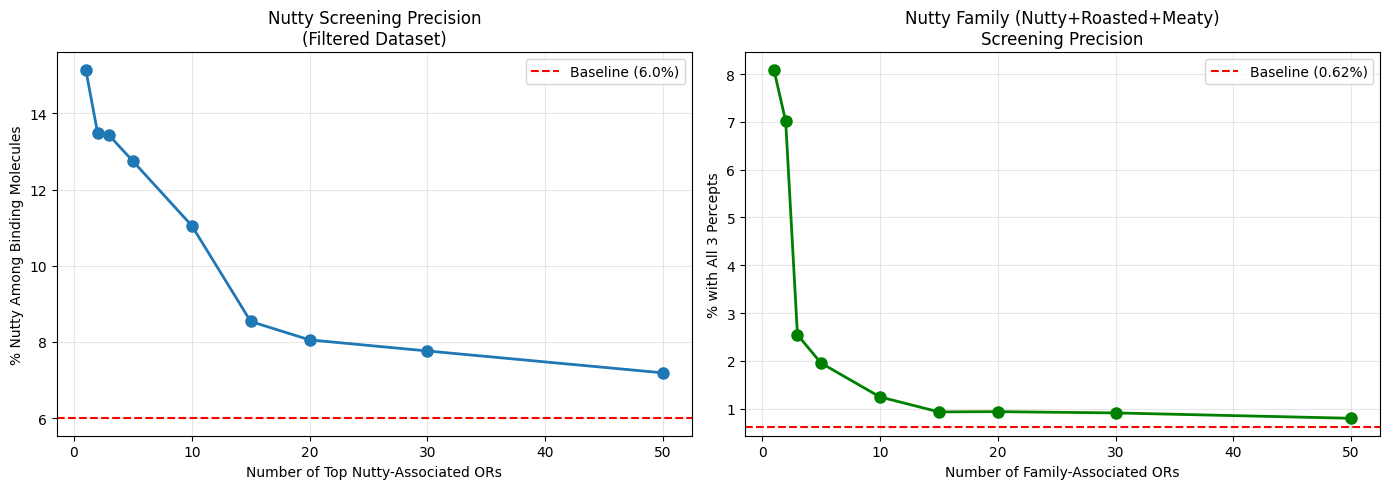

In [19]:
# Visualize key results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Nutty enrichment by number of top ORs
sorted_or_indices = or_stats_sorted['OR_index'].tolist()
n_or_sweep = [1, 2, 3, 5, 10, 15, 20, 30, 50]
sweep_results = []

for n_ors in n_or_sweep:
    top_or_idx = sorted_or_indices[:n_ors]
    any_binding = or_preds[:, top_or_idx].sum(dim=1) > 0
    any_indices = any_binding.nonzero(as_tuple=True)[0].numpy()
    if len(any_indices) > 0:
        prop = df.iloc[any_indices]['nutty'].sum() / len(any_indices)
    else:
        prop = 0
    sweep_results.append({'n_ors': n_ors, 'proportion': prop, 'enrichment': prop/baseline_nutty_prop})

sweep_df = pd.DataFrame(sweep_results)

axes[0].plot(sweep_df['n_ors'], sweep_df['proportion'] * 100, 'o-', linewidth=2, markersize=8)
axes[0].axhline(y=baseline_nutty_prop * 100, color='red', linestyle='--', label=f'Baseline ({baseline_nutty_prop*100:.1f}%)')
axes[0].set_xlabel('Number of Top Nutty-Associated ORs')
axes[0].set_ylabel('% Nutty Among Binding Molecules')
axes[0].set_title('Nutty Screening Precision\n(Filtered Dataset)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Family enrichment
axes[1].plot(family_results_df['n_family_ORs'], family_results_df['proportion_family'] * 100, 'o-', 
             linewidth=2, markersize=8, color='green')
axes[1].axhline(y=baseline_family_prop * 100, color='red', linestyle='--', 
               label=f'Baseline ({baseline_family_prop*100:.2f}%)')
axes[1].set_xlabel('Number of Family-Associated ORs')
axes[1].set_ylabel('% with All 3 Percepts')
axes[1].set_title('Nutty Family (Nutty+Roasted+Meaty)\nScreening Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/filtered_nutty_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Save filtered results
or_stats.to_csv('../plots/filtered_nutty_or_stats.csv', index=False)
results_df.to_csv('../plots/filtered_nutty_top_ors_screening.csv', index=False)
family_results_df.to_csv('../plots/filtered_nutty_family_enrichment.csv', index=False)

print("Results saved to ../plots/")

Results saved to ../plots/
